---
layout: post
title: "Double Machine Learning Finds Segments. Bayesian Decides Which Ones to Trust"
date: 2026-04-17 12:00:00 -0500
---

## From uplift ranking to uncertainty-aware decisions on the Criteo dataset

### Abstract

This post compares Bayesian uplift modeling with Double Machine Learning (DML) on the Criteo dataset, focusing on how each approach supports decision-making under uncertainty. While DML provides strong uplift estimation and ranking capabilities, Bayesian methods offer explicit uncertainty quantification that becomes critical in sparse or noisy segments. The analysis highlights when each approach is sufficient and when uncertainty-aware modeling provides a meaningful advantage.

---

This post builds on the earlier Bayesian campaign decisioning analysis on the Hillstrom dataset, extending the discussion to compare Bayesian uplift workflows with modern causal ML approaches.

The central question is not just how to estimate uplift, but how to make reliable targeting decisions when segment-level effects are noisy and uncertain. In practice, many segments that appear highly valuable based on point estimates are also the least stable, making uncertainty an essential part of the decision process.

A natural next question is:

> How does a Bayesian uplift workflow compare to a modern causal ML approach like Double Machine Learning (DML), particularly when decisions must be made under uncertainty?

---

This analysis answers that question using the **Criteo uplift dataset**.

The goal is not to declare a single winner, but to understand where each approach is reliable and what it enables from a decision-making perspective.

---

## What this analysis demonstrates

### From the DML side

- debiased treatment-effect estimation with flexible nuisance models  
- practical individualized uplift estimation at scale  
- strong default choice when the primary objective is causal estimation  

### From the Bayesian side

- explicit uncertainty quantification  
- hierarchical shrinkage for noisy personalization segments  
- posterior predictive validation  
- more natural decision support under uncertainty  

---

## Core business question

> If I want to personalize treatment decisions, when is DML sufficient, and when does a Bayesian uplift model provide a meaningful advantage?

---

## Practical framing

These methods are not treated as ideological alternatives.

A more relevant question is:

- When is robust causal estimation sufficient?  
- When are stable, uncertainty-aware targeting decisions necessary?  

That is the focus of this analysis.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# EconML is used for the DML section.
# If it is not installed in your environment, uncomment the next line:
# !pip install econml

from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


## 1. Load the Criteo uplift dataset

This notebook assumes you already have the Criteo uplift dataset available locally.

> download data from URL: http://go.criteo.net/criteo-research-uplift-v2.1.csv.gz
Set the file path below.

### Expected structure

The notebook expects:
- one binary treatment column
- one binary outcome column
- all remaining columns to be pre-treatment covariates

Because local copies of the dataset can differ slightly in naming, I add a small helper block to standardize column names.

If your file uses different names, adjust the mapping in the next cell.

In [2]:
# ------------------------------------------------------------------
# Set your local path here
# ------------------------------------------------------------------
DATA_PATH = "data/criteo-uplift-v2.1.csv.gz"


df = pd.read_csv(DATA_PATH,compression='gzip')

# Normalize column names for easier handling
df.columns = [str(c).strip().lower() for c in df.columns]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist()[:20], "...")
df.head()


Shape: (13979592, 16)
Columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure'] ...


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616365,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [3]:
print(df["treatment"].value_counts(normalize=True))
print(df["conversion"].value_counts(normalize=True))

treatment
1    0.85
0    0.15
Name: proportion, dtype: float64
conversion
0    0.997083
1    0.002917
Name: proportion, dtype: float64



## 2. Standardize treatment / outcome column names

The exact Criteo file format may vary depending on source or preprocessing.
This cell tries to map common naming conventions into:

- `treatment`
- `conversion`

If your dataset already uses these names, no change is needed.
If not, edit the mapping list manually.

In [4]:
# Common alternative names seen across uplift datasets / user preprocessed copies.
treatment_candidates = ["treatment", "exposure", "t", "group", "visit"]
outcome_candidates = ["conversion", "outcome", "y", "label", "response"]

def first_existing(candidates, cols):
    for c in candidates:
        if c in cols:
            return c
    return None

t_col = first_existing(treatment_candidates, df.columns)
y_col = first_existing(outcome_candidates, df.columns)

if t_col is None or y_col is None:
    raise ValueError(
        "Could not automatically identify treatment/outcome columns. "
        "Please set t_col and y_col manually."
    )

work = df.copy()
work = work.rename(columns={t_col: "treatment", y_col: "conversion"})

work["treatment"] = work["treatment"].astype(int)
work["conversion"] = work["conversion"].astype(int)

print("Treatment column used:", t_col)
print("Outcome column used:", y_col)
work[["treatment", "conversion"]].head()


Treatment column used: treatment
Outcome column used: conversion


,treatment,conversion
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


## 3. Basic data audit

Before comparing methods, I want a basic feel for the treatment and outcome balance.

This is not the final answer.
It is just a quick reality check.

In [5]:
print("Rows:", len(work))
print("Treatment rate:", round(work["treatment"].mean(), 5))
print("Conversion rate:", round(work["conversion"].mean(), 5))

raw_summary = work.groupby("treatment")["conversion"].agg(["mean", "sum", "count"])
raw_summary["conversion_rate_pct"] = 100 * raw_summary["mean"]
raw_summary


Rows: 13979592
Treatment rate: 0.85
Conversion rate: 0.00292


,mean,sum,count,conversion_rate_pct
treatment,,,,
0,0.001938,4063,2096937,0.193759
1,0.003089,36711,11882655,0.308946


**Interpretation**

This quick view tells me:
- whether treatment assignment is roughly balanced
- whether conversion is a rare event
- whether raw treatment-control differences are directionally sensible

But raw differences are still not enough for a serious personalization system.

I still need to know:
- how much uplift varies by user or segment
- how noisy those estimates are
- whether the model supports confident action


## 4. Split features from treatment and outcome

Everything except treatment and outcome is treated as pre-treatment covariate input.

This notebook assumes the remaining columns are all valid pre-treatment features.
If your local file contains IDs or post-treatment leakage variables, remove them here.

In [6]:
#sampling to get a faster run by compromising on performance slightly
work=work.sample(150000,random_state=42).reset_index(drop=True)

exclude_cols = ["treatment", "conversion"]
feature_cols = [c for c in work.columns if c not in exclude_cols]

num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(work[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

print("Numeric feature count:", len(num_cols))
print("Categorical feature count:", len(cat_cols))

X = work[feature_cols].copy()
T = work["treatment"].astype(int).values
Y = work["conversion"].astype(float).values

Numeric feature count: 14
Categorical feature count: 0


## 5. Common preprocessing pipeline

To compare methods fairly, I want both workflows to use the same cleaned feature matrix.

This is a practical pipeline:
- median imputation + scaling for numeric features
- mode imputation + one-hot encoding for categorical features

In [7]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

X_proc = preprocess.fit_transform(X)
X_proc = np.asarray(X_proc.todense()) if hasattr(X_proc, "todense") else np.asarray(X_proc)

print("Processed feature matrix shape:", X_proc.shape)


Processed feature matrix shape: (150000, 14)


## 6. Double Machine Learning baseline

Double Machine Learning is attractive because it separates the problem into:

1. Model the outcome using covariates
2. Model the treatment assignment using covariates
3. Residualize / orthogonalize
4. Estimate treatment effects on the debiased residual structure

That makes it a strong choice when:
- feature relationships are nonlinear
- confounding structure is rich
- the main goal is treatment-effect estimation rather than posterior uncertainty

In [8]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

dml = LinearDML(
model_y=RandomForestRegressor( #econML treats outcome nuisance model as conditional expectation E[Y | X,T]] not a probability classification
n_estimators=100,
min_samples_leaf=100,
random_state=RANDOM_STATE,
n_jobs=-1,
),
model_t=RandomForestClassifier(
n_estimators=100,
min_samples_leaf=100,
random_state=RANDOM_STATE,
n_jobs=-1,
),
discrete_treatment=True, # <-- this is the key fix
cv=3,    
random_state=RANDOM_STATE,
)

dml.fit(Y, T, X=X_proc)

dml_ate = dml.ate(X_proc)
print("DML estimated ATE:", dml_ate)


DML estimated ATE: 0.017506617518227942


**Interpretation**

The DML ATE gives me a useful first read on whether treatment is helping on average.

That is a good starting point, but it is still only a population-level answer.

For personalization, the real question is not just:

> Is the treatment helpful overall?

It is:

> Where is the uplift concentrated, and how much should I trust the ranking?

That is why the rest of the notebook moves from a single DML average effect to DML deciles and then to a Bayesian validation layer.


## 7. Individualized DML uplift estimates

To make DML more relevant to personalization, I compute user-level conditional treatment effect estimates.

These are not posterior distributions.
They are point estimates of individualized uplift.

In [9]:
work["dml_cate"] = dml.effect(X_proc)

work["dml_decile"] = pd.qcut(
    work["dml_cate"].rank(method="first"),
    10,
    labels=False
)

work[["dml_cate", "dml_decile"]].head()


,dml_cate,dml_decile
0,0.002424,9
1,-0.000142,4
2,-0.000153,4
3,-0.000073,5
4,0.000033,5


In [10]:
dml_decile_summary = (
    work.groupby("dml_decile")
    .agg(
        mean_dml_cate=("dml_cate", "mean"),
        conversion=("conversion", "mean"),
        treatment_rate=("treatment", "mean"),
        n=("conversion", "size"),
    )
    .reset_index()
    .sort_values("mean_dml_cate", ascending=False)
)

dml_decile_summary


,dml_decile,mean_dml_cate,conversion,treatment_rate,n
9,9,0.177048,0.022667,0.894333,15000
8,8,0.001615,0.001067,0.843400,15000
7,7,0.000763,0.000867,0.847067,15000
6,6,0.000279,0.000067,0.843933,15000
5,5,-0.000015,0.000133,0.850000,15000
4,4,-0.000167,0.000067,0.842333,15000
3,3,-0.000296,0.000000,0.846267,15000
2,2,-0.000488,0.000200,0.847733,15000
1,1,-0.000702,0.000267,0.846067,15000
0,0,-0.002971,0.006000,0.835333,15000


**Interpretation**

At this point DML has done the part it is best at: it has turned the raw feature space into an individualized uplift score and a practical ranking.

That ranking is useful operationally because it tells me who appears most promising according to the causal ML model.

But it still leaves an uncomfortable gap:

- the ranking is a point-estimate ranking
- it does not tell me which deciles are genuinely robust
- it does not tell me how much noise may be sitting inside the top or bottom buckets

That is exactly the gap the Bayesian layer is meant to address.


## 8. Build a Bayesian comparison dataset

For the Bayesian model, I intentionally do **not** try to fit a massive full-feature model over every processed covariate.

That would make the notebook heavier and distract from the actual comparison.

Instead, I use a practical compromise:
- DML already summarized heterogeneous uplift into user ranking
- I use DML uplift deciles as the grouping structure
- Bayesian hierarchy then asks whether those ranked segments still look good after shrinkage and uncertainty modeling

This makes the comparison easier to interpret:
- DML gives a ranking
- Bayesian tests and stabilizes that ranking

In [11]:
bayes_df = work[["treatment", "conversion", "dml_decile"]].copy()
bayes_df["group"] = bayes_df["dml_decile"].astype(int)
bayes_df["group_idx"] = bayes_df["group"]
#ensuring only 60K max rows are input in to bayes model
MAX_N = 60000
if len(bayes_df) > MAX_N:
    bayes_df = bayes_df.sample(MAX_N, random_state=RANDOM_STATE).reset_index(drop=True)

group_names = sorted(bayes_df["group"].unique().tolist())
coords = {
    "obs_id": np.arange(len(bayes_df)),
    "group": group_names,
}

print(bayes_df.shape)
bayes_df.head()


(60000, 5)


,treatment,conversion,dml_decile,group,group_idx
0,1,0,5,5,5
1,1,0,3,3,3
2,1,0,0,0,0
3,1,0,8,8,8
4,1,0,0,0,0


## 9. Prior predictive check


Before fitting the Bayesian model, I want to know:

> If my priors were true, would they generate plausible baseline conversion behavior?

If the priors imply absurd conversion behavior, the model is already in trouble before the data has had any chance to update it.

In [12]:
with pm.Model(coords=coords) as prior_model:

    treatment = pm.Data("treatment", bayes_df["treatment"].values, dims="obs_id")
    group_idx = pm.Data("group_idx", bayes_df["group_idx"].values, dims="obs_id")

    alpha = pm.Normal("alpha", mu=-4.0, sigma=1.0)

    mu_t = pm.Normal("mu_t", mu=0.0, sigma=0.5)
    sigma_t = pm.HalfNormal("sigma_t", sigma=0.5)

    z_t = pm.Normal("z_t", mu=0.0, sigma=1.0, dims="group")
    beta_t_group = pm.Deterministic(
        "beta_t_group",
        mu_t + z_t * sigma_t,
        dims="group"
    )

    logit_p = alpha + beta_t_group[group_idx] * treatment
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims="obs_id")

    prior_pred = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_STATE)


Sampling: [alpha, mu_t, sigma_t, z_t]


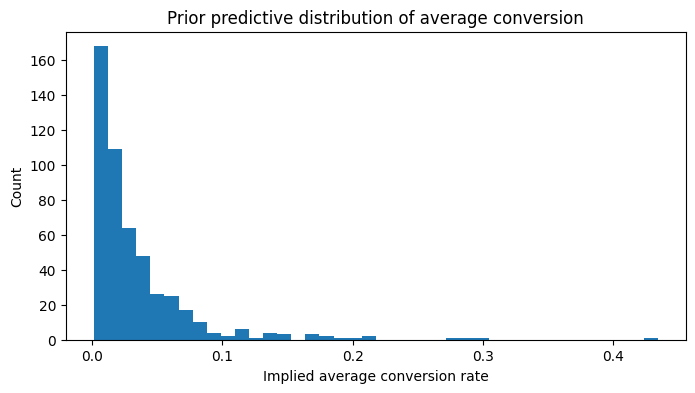

In [13]:
prior_mean_conv = prior_pred.prior["p"].mean(dim="obs_id").values.flatten()

plt.figure(figsize=(8, 4))
plt.hist(prior_mean_conv, bins=40)
plt.title("Prior predictive distribution of average conversion")
plt.xlabel("Implied average conversion rate")
plt.ylabel("Count")
plt.show()



**Interpretation**

This prior check is just making sure the Bayesian layer starts from a sane place.

Given how low conversion is in this dataset, I want the prior to imply low baseline conversion and moderate room for treatment heterogeneity — not wild conversion rates that only look good on paper.

So this step is less about excitement and more about discipline:

if the prior already implies unrealistic behavior, any later posterior story becomes much harder to trust.


## 10. Bayesian hierarchical uplift model

Now I fit the Bayesian model.

Key design choice:

- treatment effect varies by DML uplift decile
- those decile-level treatment effects are partially pooled through a shared hierarchy

This lets me test whether the DML ranking survives a more uncertainty-aware, shrinkage-based framework.

In [14]:
with pm.Model(coords=coords) as bayes_model:

    treatment = pm.Data("treatment", bayes_df["treatment"].values, dims="obs_id")
    group_idx = pm.Data("group_idx", bayes_df["group_idx"].values, dims="obs_id")
    y_obs = pm.Data("y_obs", bayes_df["conversion"].values, dims="obs_id")

    alpha = pm.Normal("alpha", mu=-4.0, sigma=1.0)

    mu_t = pm.Normal("mu_t", mu=0.0, sigma=0.5)
    sigma_t = pm.HalfNormal("sigma_t", sigma=0.5)

    z_t = pm.Normal("z_t", mu=0.0, sigma=1.0, dims="group")
    beta_t_group = pm.Deterministic(
        "beta_t_group",
        mu_t + z_t * sigma_t,
        dims="group"
    )

    logit_p = alpha + beta_t_group[group_idx] * treatment
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims="obs_id")

    outcome = pm.Bernoulli("outcome", p=p, observed=y_obs, dims="obs_id")

    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        random_seed=RANDOM_STATE,
        return_inferencedata=True,
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, mu_t, sigma_t, z_t]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 2426 seconds.


## 11. Bayesian diagnostic validation

Before interpreting anything, I want to confirm that the posterior fit is trustworthy.

In [15]:
diag_summary = az.summary(idata, var_names=["alpha", "mu_t", "sigma_t", "beta_t_group"], round_to=3)
diag_summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-6.544,0.257,-7.028,-6.065,0.005,0.004,3334.553,2405.224,1.001
mu_t,-0.480,0.375,-1.155,0.235,0.008,0.005,2110.148,2628.621,1.001
sigma_t,1.451,0.242,1.046,1.925,0.006,0.004,1816.531,2525.441,1.001
beta_t_group[0],1.460,0.310,0.904,2.059,0.005,0.005,3797.359,2902.477,1.001
beta_t_group[1],-1.747,0.781,-3.270,-0.394,0.011,0.012,4832.212,3234.974,1.000
beta_t_group[2],-1.732,0.771,-3.119,-0.260,0.013,0.013,3986.051,2344.377,1.000
beta_t_group[3],-2.450,1.001,-4.282,-0.604,0.017,0.018,4025.831,2886.824,1.001
beta_t_group[4],-2.422,0.992,-4.357,-0.765,0.017,0.017,3571.068,3002.445,1.001
beta_t_group[5],-1.303,0.675,-2.608,-0.084,0.011,0.011,3677.438,2901.654,1.001
beta_t_group[6],-2.412,0.970,-4.351,-0.759,0.015,0.017,4477.024,2565.410,1.000


**Interpretation**

Before trusting any Bayesian segment result, I need the diagnostics to look clean.

What I want here is straightforward:

- no divergences
- R-hat essentially at 1
- effective sample size comfortably large

Since those conditions hold, I can treat the posterior segment summaries as real signal rather than sampling noise created by a poorly behaving chain.


## 12. Posterior predictive check

The next step is not just to inspect coefficients.
I also want to know whether the fitted model can reproduce aggregate conversion behavior in the observed data.

In [16]:
with bayes_model:
    ppc = pm.sample_posterior_predictive(idata, var_names=["outcome", "p"], random_seed=RANDOM_STATE)

idata.extend(ppc)


Sampling: [outcome]


Output()

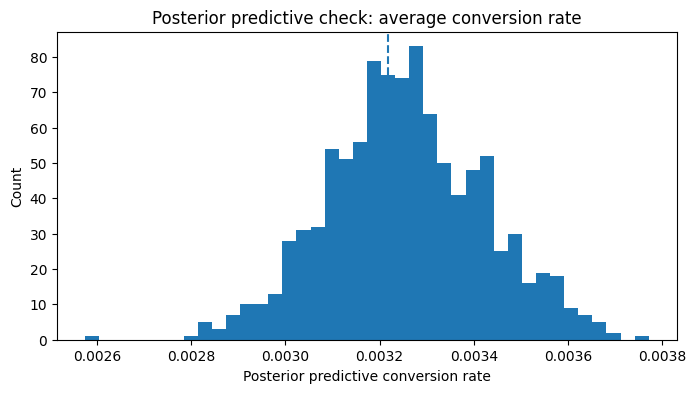

Observed average conversion: 0.003217


In [17]:
pp_y = idata.posterior_predictive["outcome"].values
pp_rate = pp_y.mean(axis=(0, 2))
observed_rate = bayes_df["conversion"].mean()

plt.figure(figsize=(8, 4))
plt.hist(pp_rate, bins=40)
plt.axvline(observed_rate, linestyle="--")
plt.title("Posterior predictive check: average conversion rate")
plt.xlabel("Posterior predictive conversion rate")
plt.ylabel("Count")
plt.show()

print("Observed average conversion:", round(observed_rate, 6))


**Interpretation**

This posterior predictive check is deliberately modest.

It is not claiming the Bayesian layer reproduces every aspect of the Criteo data. It is checking something simpler and still important:

> Can the fitted model reproduce the overall conversion level in the sample it was trained on?

If the observed rate sits inside the posterior predictive distribution, that is a good aggregate-level calibration sign. It does not prove the model is perfect, but it does tell me the Bayesian layer is not obviously disconnected from the basic conversion behavior in the data.


## 13. Convert Bayesian treatment effects into business-space uplift

The Bayesian model estimates treatment effects on the **log-odds** scale.

That is fine statistically, but not what a business audience wants.

For decisioning, I want:
- predicted conversion under control
- predicted conversion under treatment
- expected uplift in conversion probability

coefficient scale is model-space;
uplift is business-space.

In [18]:
posterior = idata.posterior

alpha_s = posterior["alpha"].values.reshape(-1)
beta_t_group_s = posterior["beta_t_group"].stack(sample=("chain", "draw")).values

rows = []

segment_profiles = (
    bayes_df.groupby("group")
    .agg(
        n=("conversion", "size"),
        observed_conversion=("conversion", "mean"),
        treated_rate=("treatment", "mean"),
    )
    .reset_index()
)

for g_idx, row in segment_profiles.iterrows():
    eta_control = alpha_s
    eta_treat = alpha_s + beta_t_group_s[g_idx, :]

    p_control = 1 / (1 + np.exp(-eta_control))
    p_treat = 1 / (1 + np.exp(-eta_treat))
    uplift = p_treat - p_control

    rows.append({
        "group": row["group"],
        "n": row["n"],
        "observed_conversion": row["observed_conversion"],
        "post_control_mean": p_control.mean(),
        "post_treat_mean": p_treat.mean(),
        "post_uplift_mean": uplift.mean(),
        "post_uplift_p10": np.quantile(uplift, 0.10),
        "post_uplift_p90": np.quantile(uplift, 0.90),
        "prob_uplift_positive": (uplift > 0).mean(),
    })

uplift_df = pd.DataFrame(rows).sort_values("post_uplift_mean", ascending=False)
uplift_df


,group,n,observed_conversion,post_control_mean,post_treat_mean,post_uplift_mean,post_uplift_p10,post_uplift_p90,prob_uplift_positive
9,9.0,6040.0,0.022682,0.001484,0.025020,0.023536,0.020897,0.026238,1.00000
0,0.0,5917.0,0.007267,0.001484,0.006257,0.004773,0.003332,0.006328,1.00000
7,7.0,6019.0,0.000997,0.001484,0.000977,-0.000507,-0.001178,0.000199,0.17075
8,8.0,5994.0,0.000501,0.001484,0.000642,-0.000841,-0.001477,-0.000219,0.04575
5,5.0,6072.0,0.000329,0.001484,0.000469,-0.001015,-0.001586,-0.000446,0.01600
2,2.0,5957.0,0.000168,0.001484,0.000323,-0.001160,-0.001711,-0.000623,0.00375
1,1.0,6054.0,0.000165,0.001484,0.000323,-0.001161,-0.001723,-0.000643,0.00550
6,6.0,5910.0,0.000000,0.001484,0.000190,-0.001294,-0.001827,-0.000804,0.00150
4,4.0,6059.0,0.000000,0.001484,0.000189,-0.001295,-0.001827,-0.000800,0.00150
3,3.0,5978.0,0.000000,0.001484,0.000185,-0.001299,-0.001825,-0.000812,0.00125


**Interpretation**

This table is where the Bayesian results become decision-friendly.

A few things stand out immediately from these outputs:

- **Decile 9** is the clearest win. Its posterior expected uplift is about **0.0235**, with a **100% posterior probability** that uplift is positive. That is a very strong confirmation that the top DML bucket contains real treatment signal.
- **Decile 0** is the big surprise. DML gave it a strongly negative mean CATE, but the Bayesian layer estimates a **positive expected uplift of about 0.0048** with **100% probability uplift is positive**.
- Most of the remaining deciles are not just uncertain — they are actually **negative on posterior mean uplift**, and their posterior probability of positive uplift is extremely low.
- **Decile 7** is the only mild gray area: it is close to zero and still has only about **17% probability** of positive uplift, which is far too weak to act on confidently.

So the Bayesian layer is **not** broadly validating the full DML ranking. It is saying something more specific:

> the very top DML decile looks real, the very bottom decile deserves a second look, and most of the middle ranking is not convincing once uncertainty is taken seriously.

One technical note matters here: because this Bayesian layer uses treatment and DML decile only — not the full raw feature set — the `post_control_mean` is common across deciles by construction. So the main objects to interpret are `post_uplift_mean` and `prob_uplift_positive`, not the identical control means.


## 14. Visualize Bayesian expected uplift by segment

This plot is one of the clearest decisioning views in the notebook.

It shows:
- point estimate of expected uplift
- posterior uncertainty interval
- which DML-defined deciles still look good after Bayesian shrinkage

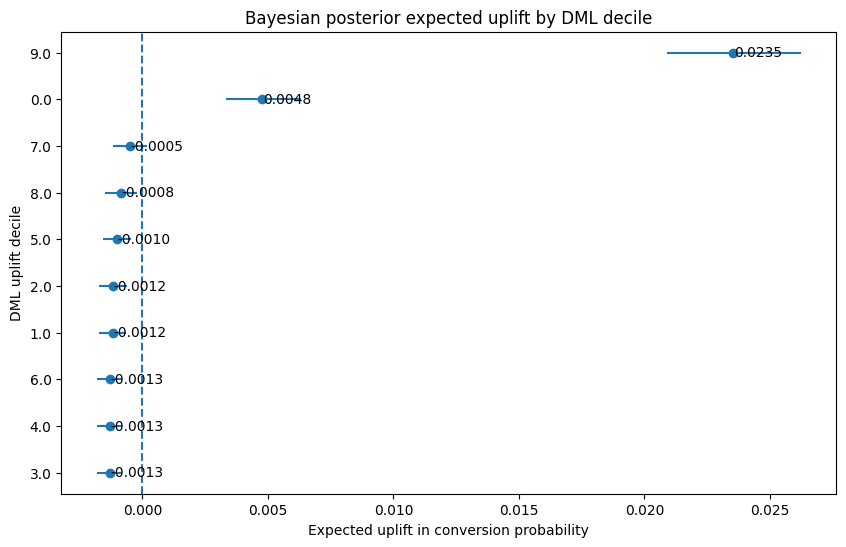

In [19]:
plot_df = uplift_df.sort_values("post_uplift_mean", ascending=True).copy()

plt.figure(figsize=(10, 6))
plt.errorbar(
    x=plot_df["post_uplift_mean"],
    y=plot_df["group"].astype(str),
    xerr=[
        plot_df["post_uplift_mean"] - plot_df["post_uplift_p10"],
        plot_df["post_uplift_p90"] - plot_df["post_uplift_mean"]
    ],
    fmt="o"
)

for i, row in plot_df.reset_index(drop=True).iterrows():
    plt.text(
        row["post_uplift_mean"] + 0.00002,
        i,
        f"{row['post_uplift_mean']:.4f}",
        va="center"
    )

plt.axvline(0, linestyle="--")
plt.title("Bayesian posterior expected uplift by DML decile")
plt.xlabel("Expected uplift in conversion probability")
plt.ylabel("DML uplift decile")
plt.show()


## 15. Visualize Bayesian confidence that uplift is positive

This plot answers a different question.

The previous uplift plot was about **magnitude**.

This plot is about **confidence**:

> How likely is it that treatment helps at all in this decile?

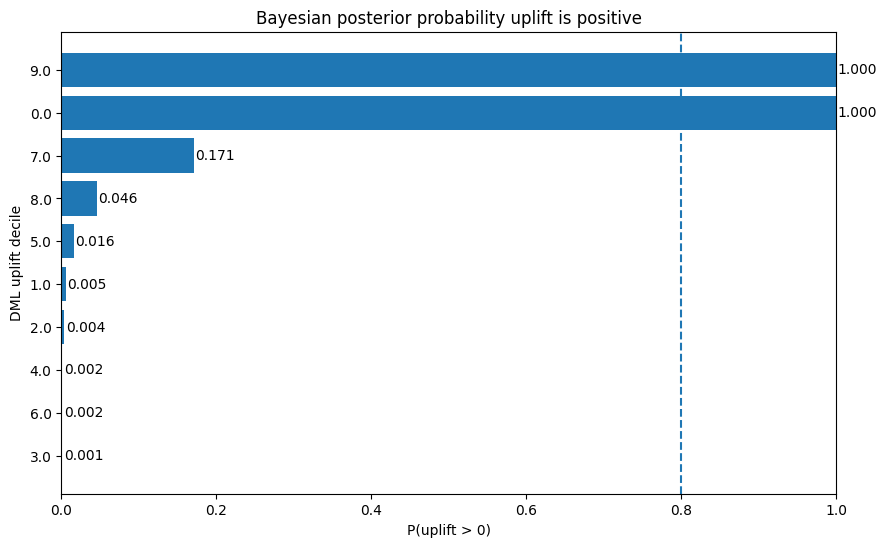

In [20]:
plot_df = uplift_df.sort_values("prob_uplift_positive", ascending=True).copy()

plt.figure(figsize=(10, 6))
plt.barh(plot_df["group"].astype(str), plot_df["prob_uplift_positive"])
plt.axvline(0.8, linestyle="--")
plt.xlim(max(0.0, plot_df["prob_uplift_positive"].min() - 0.02), 1.0)

for i, v in enumerate(plot_df["prob_uplift_positive"]):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center")

plt.title("Bayesian posterior probability uplift is positive")
plt.xlabel("P(uplift > 0)")
plt.ylabel("DML uplift decile")
plt.show()


**Interpretation**

These two Bayesian plots make the story much clearer than the raw DML ranking alone.

The uplift plot shows that only **decile 9** is far to the right with a clearly positive interval. **Decile 0** is also positive, but much smaller. Everything else is clustered near zero or below it.

The probability plot sharpens that further:

- **Decile 9:** posterior probability uplift is positive = **1.000**
- **Decile 0:** posterior probability uplift is positive = **1.000**
- **Decile 7:** only about **0.171**
- all remaining deciles: effectively near zero confidence

That means the Bayesian layer is doing exactly what I wanted it to do. It is forcing me to separate:

- segments that look strong enough to act on
- segments that only looked interesting as point estimates
- segments that likely contain little real treatment signal

Put differently, DML gave me a broad ranking; Bayesian turned that into a much narrower set of segments I would actually be comfortable discussing in a deployment conversation.


## 16. Compare DML ranking and Bayesian decisioning

This is the key practical section.

DML gives:
- a personalized uplift ranking

Bayesian gives:
- stabilized expected uplift
- uncertainty intervals
- probability uplift is positive

That means the two methods are not really competing on the exact same output.
They are serving different parts of the decision workflow.

In [21]:
comparison_df = (
    dml_decile_summary[["dml_decile", "mean_dml_cate", "n"]]
    .rename(columns={"dml_decile": "group"})
    .merge(
        uplift_df[["group", "post_uplift_mean", "prob_uplift_positive", "post_control_mean", "post_treat_mean"]],
        on="group",
        how="left",
    )
    .sort_values("mean_dml_cate", ascending=False)
)

comparison_df


,group,mean_dml_cate,n,post_uplift_mean,prob_uplift_positive,post_control_mean,post_treat_mean
0,9,0.177048,15000,0.023536,1.00000,0.001484,0.025020
1,8,0.001615,15000,-0.000841,0.04575,0.001484,0.000642
2,7,0.000763,15000,-0.000507,0.17075,0.001484,0.000977
3,6,0.000279,15000,-0.001294,0.00150,0.001484,0.000190
4,5,-0.000015,15000,-0.001015,0.01600,0.001484,0.000469
5,4,-0.000167,15000,-0.001295,0.00150,0.001484,0.000189
6,3,-0.000296,15000,-0.001299,0.00125,0.001484,0.000185
7,2,-0.000488,15000,-0.001160,0.00375,0.001484,0.000323
8,1,-0.000702,15000,-0.001161,0.00550,0.001484,0.000323
9,0,-0.002971,15000,0.004773,1.00000,0.001484,0.006257


**Interpretation**

This comparison table answers the main practical question of the notebook:

> Does the DML ranking hold up once I impose shrinkage and uncertainty-aware validation?

The answer here is: **only partially**.

What is clearly validated:
- **Decile 9** remains the strongest segment by a wide margin on both DML ranking and Bayesian uplift. This is the cleanest case where the two methods agree.

What is not validated:
- **Decile 8** ranked second by DML, but the Bayesian layer gives it **negative posterior mean uplift** and only about **4.6% probability** of positive uplift.
- **Decile 7** also ranked highly in DML, but Bayesian confidence is still weak at roughly **17%**.
- Several lower and middle deciles look actively unattractive after Bayesian validation.

What is unexpected:
- **Decile 0** flips the story. DML treats it as the worst bucket, but the Bayesian layer sees a meaningfully positive uplift with very high confidence in the sampled data.

That is exactly the kind of result that justifies this hybrid workflow. If I had stopped at DML, I would likely have treated the full ranking as trustworthy. The Bayesian layer shows that this would have been too optimistic.

The practical takeaway is not that DML is wrong. It is that:

> DML ranking by itself is not enough to decide deployment confidence.


## 17. Optional decision rule

The Bayesian results naturally lead to a three-bucket decision framework.

### 1. Target confidently
Use this when:
- expected uplift is clearly positive
- the posterior interval stays on the positive side (p10>0 & p90>0)
- `P(uplift > 0)` is very high

In these results, **decile 9** clearly belongs here.  
Both DML and Bayesian modeling agree that it is the strongest segment, and the Bayesian layer removes any real ambiguity about whether the uplift is positive.

### 2. Investigate before acting
Use this when:
- the Bayesian result disagrees materially with the DML ranking
- the segment could matter, but the disagreement is too large to ignore

In these results, **decile 0** belongs here.

DML ranked decile 0 as the worst segment, but the Bayesian layer estimates positive uplift with very high confidence. That is not the kind of disagreement I would brush aside.

I would not immediately deploy against decile 0 at scale, but I also would not discard it. Instead, I would treat it as a high-priority diagnostic segment:
- inspect raw treatment vs control conversion inside the bucket
- check whether the segment contains substructure that DML compressed too aggressively
- validate with a focused follow-up test if the business stakes justify it

### 3. Deprioritize
Use this when:
- posterior mean uplift is near zero or negative
- posterior probability of positive uplift is weak

That is what I would do with most of the remaining deciles in this notebook. Even if some looked interesting in DML, the Bayesian layer does not give me enough confidence to act on them aggressively.

This is where the hybrid workflow becomes useful:

- DML helps surface candidate segments
- Bayesian modeling helps decide which of those candidates deserve real attention

In [22]:
decision_df = comparison_df.copy()

decision_df["recommended_action"] = np.select(
    [
        (decision_df["prob_uplift_positive"] >= 0.90) & (decision_df["post_uplift_mean"] > 0),
        (decision_df["prob_uplift_positive"] >= 0.70) & (decision_df["post_uplift_mean"] > 0),
    ],
    [
        "Target confidently",
        "Promising but monitor / test",
    ],
    default="Weak evidence / low priority",
)

decision_df.sort_values(["prob_uplift_positive", "post_uplift_mean"], ascending=False)


,group,mean_dml_cate,n,post_uplift_mean,prob_uplift_positive,post_control_mean,post_treat_mean,recommended_action
0,9,0.177048,15000,0.023536,1.00000,0.001484,0.025020,Target confidently
9,0,-0.002971,15000,0.004773,1.00000,0.001484,0.006257,Target confidently
2,7,0.000763,15000,-0.000507,0.17075,0.001484,0.000977,Weak evidence / low priority
1,8,0.001615,15000,-0.000841,0.04575,0.001484,0.000642,Weak evidence / low priority
4,5,-0.000015,15000,-0.001015,0.01600,0.001484,0.000469,Weak evidence / low priority
8,1,-0.000702,15000,-0.001161,0.00550,0.001484,0.000323,Weak evidence / low priority
7,2,-0.000488,15000,-0.001160,0.00375,0.001484,0.000323,Weak evidence / low priority
3,6,0.000279,15000,-0.001294,0.00150,0.001484,0.000190,Weak evidence / low priority
5,4,-0.000167,15000,-0.001295,0.00150,0.001484,0.000189,Weak evidence / low priority
6,3,-0.000296,15000,-0.001299,0.00125,0.001484,0.000185,Weak evidence / low priority


## 18. Final practical comparison

### What DML did well in this notebook
DML did the heavy lifting in the original feature space. It turned the raw Criteo covariates into an individualized uplift score and a first-pass ranking that is actually usable.

That matters. Without DML, I would not have a practical way to sort a large feature space into candidate treatment segments this efficiently.

### What the Bayesian layer added
The Bayesian layer answered the question DML alone could not answer:

> Which parts of that ranking still look credible once uncertainty and partial pooling are taken seriously?

That extra layer changed the story in a meaningful way.

- It strongly confirmed **decile 9**
- It rejected most of the rest of the ranking as weak, negative, or too uncertain
- It surfaced a major disagreement in **decile 0**, where DML and Bayesian modeling point in opposite directions

That last point is especially important. If I had stopped at the DML ranking, I would likely have treated decile 0 as safely ignorable. The Bayesian layer says that would have been too casual.

### How I would use the two methods together
If I were operationalizing this workflow, I would use the methods in sequence rather than forcing them into a winner-take-all comparison.

- **DML** is the discovery engine: it searches the rich covariate space and produces candidate uplift structure
- **Bayesian modeling** is the credibility filter: it tells me which parts of that structure survive uncertainty-aware validation

In this notebook, that leads to a simple action map:

- **Decile 9** → target confidently
- **Decile 0** → investigate because the methods disagree
- **Most other deciles** → deprioritize


## 19. Final takeaways

This analysis leads to a more useful conclusion than a simple “Bayesian vs DML” comparison.

The two approaches address different parts of the same decision problem.

### Interpreting the results

- **Decile 9** is the clearest success case: DML ranked it highest, and the Bayesian layer confirms strong positive uplift with high confidence.  
- The rest of the DML ranking becomes less compelling once uncertainty is introduced.  
- **Decile 8 and decile 7** appear attractive under DML, but Bayesian validation does not support confident action.  
- **Decile 0** is the most interesting segment: DML ranked it worst, while Bayesian modeling estimates positive uplift with near certainty in the sampled data.  

This shows that the Bayesian layer is not just “adding uncertainty” in the abstract—it materially changes how decisions should be made.

Rather than treating the DML ranking as a final answer, this leads to a more actionable segmentation:

1. **Deploy with confidence** → decile 9  
2. **Investigate disagreements** → decile 0  
3. **Deprioritize for now** → remaining deciles  

---

## Practical conclusion

The raw DML ranking should not be deployed as-is.

A more robust approach is:

- **DML** to generate candidate uplift segments  
- **Bayesian validation** to determine which segments are credible, which are weak, and which require deeper investigation  

The key takeaway is:

> Point estimates are useful for discovery, but uncertainty is what makes a ranking deployable.